#**Laboratorio di Introduzione alla Matematica Computazionale - Esercizi in Julia**

##**Esercitazione 5: Polinomi**

---
#1. Polinomi in Julia

In Julia, lavoriamo con i polinomi usando il pacchetto `Polynomials.jl`. Specificamente, Julia utilizza un tipo di dato specifico `Polynomial` dove i coefficienti sono ordinati dal grado più basso al più alto (ordine naturale).

Carichiamo le librerie necessarie.

In [58]:
import Pkg; Pkg.add("Polynomials")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [59]:
using Polynomials
using LinearAlgebra
using Plots

Per esempio, il polinomio
$$
p(x)=x^5+2x^4-5x^3+x-6
$$
si può rappresentare come

```julia
p = Polynomial([-6, 1, 0, -5, 2, 1])
```

Alcuni comandi utili per lavorare con i polinomi sono i seguenti (potete cercare uso e sintassi con la funzionalità `?`):
* Valutazione: `p(x)`
* Radici: `roots(p)`
* Prodotto: `p * q`
* Divisione: `divrem(p, q)`
* Derivata: `derivative(p)`


In [ ]:
p=Polynomial([1, 0, 1])
p=p+0.1


Polynomial(1.1 + 1.0*x^2)

Per fare pratica, provate a definire in Julia il polinomio $p(x)=x^2-x-1$, calcolate le sue radici e verificate che il polinomio si annulla numericamente in corrispondenza delle radici calcolate:

```julia
# Esempio: p(x) = x^2 - x - 1
# In Julia i coefficienti partono da x^0: [-1, -1, 1]
p = Polynomial([-1, -1, 1])
r = roots(p)
println("Radici: ", r)
println("Verifica p(r): ", p.(r))
```

In [ ]:
p = Polynomial([-1, -1, 1])
r = roots(p)
println("Radici: ", r)
println("Verifica p(r): ", p.(r))

Radici: [-0.6180339887498948, 1.618033988749895]
Verifica p(r): [-5.817207032317949e-17, 1.21465788570442e-16]


Viceversa, scegliamo un vettore `r` contenente le radici e calcoliamo i coefficienti del polinomio monico `p` corrispondente, quindi verifichiamo che `p` si annulli sulle radici assegnate e che il calcolo numerico delle radici di `p` restituisca gli stessi valori assegnati all'inizio:

```julia
# Definire le radici
radici = [1, 2, 3]

# Calcolare il polinomio: (x-1)(x-2)(x-3) = -6 + 11x - 6x² + x³
p = fromroots(radici)

#  Mostrare il polinomio
println(p)
# Output: Polynomial(-6 + 11*x - 6*x^2 + x^3)

# Valutare il polinomio nelle radici
println(p.(radici))

# Calcolare le radici del polinomio
radicivar = roots(p)
```


In [ ]:
Radici = [1, 2, 3]
p=fromroots(Radici)
println(p)
println(p.(Radici))
radicivar = roots(p)

-6 + 11*x - 6*x^2 + x^3
[0, 0, 0]


3-element Vector{Float64}:
 1.0000000000000002
 1.999999999999998
 3.0000000000000018

La funzione `fromroots` permette anche di calcolare il polinomio caratteristico di una matrice. Per esempio, definiamo $p(x)$ come il polinomio caratteristico della matrice
$$
A=\left[\begin{array}{cc}
0&1\\1&1 \end{array}\right].
$$
Il teorema di Cayley-Hamilton implica che $p(A)=0$. Verifichiamolo numericamente:
```julia
A=[0 1; 1 1]
p = fromroots(eigvals(A))
println(p)
println(p(A))
```
Dall'ultimo comando, dovreste ottenere una matrice numericamente nulla.

In [ ]:
A=[0 1; 1 1]
p = fromroots(eigvals(A))
println(p)
println(p(A))

-1.0 - 1.0*x + 1.0*x^2
[1.1102230246251565e-16 0.0; 0.0 1.1102230246251565e-16]


Usando `*` e `divrem` possiamo moltiplicare e dividere polinomi. Per esempio, definiamo $p(x)=x^3-6x^2+12x-8$, dividiamo $p(x)$ per $q(x)=x-2$, poi moltiplichiamo il risultato di nuovo per $q(x)$ e aggiungiamo il resto, e verifichiamo di aver ottenuto proprio $p(x)$:
```julia
p=Polynomial([-8, 12, -6, 1])
q=Polynomial([-2, 1])
(g, r) = divrem(p,q)
println(g*q+r)
```

In [ ]:
p=Polynomial([-8, 12, -6, 1])
q=Polynomial([-2, 1])
(g, r) = divrem(p,q)
println(g*q+r)

-8.0 + 12.0*x - 6.0*x^2 + 1.0*x^3


Per tracciare il grafico di una funzione polinomiale definita su un intervallo $[a,b]$ possiamo valutare il polinomio su una discretizzazione dell'intervallo e applicare il comando `plot` ai risultati ottenuti. Per esempio, supponiamo di voler tracciare il grafico di $p(x)=x^4-9x^3+21x^2+x-30$ definito sull'intervallo $[-2,6]$:
```julia
p_coeffs = [-30, 1, 21, -9, 1]
p = Polynomial(p_coeffs)
# Generare 500 punti equispaziati fra -2 e 6
t = range(-2, 6, length=500)
# Valutare il polinomio in ogni punto in t
pv = p.(t)
# Grafico
plot(t, pv, label="p(x)", title="Grafico del Polinomio", lw=2)
```

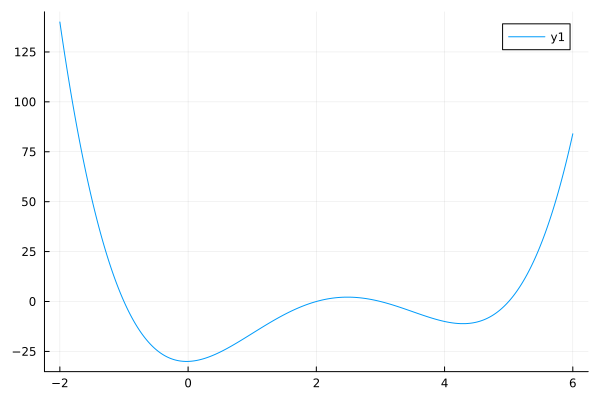

In [ ]:
coeff=[-30, 1, 21, -9, 1]
p=Polynomial(coeff)

t=range(-2.0, 6.0, length=500)
y=p.(t)

plot(t, y)

**Esercizio 1**. Scrivere una funzione `perturbed_poly(p,t)` che prenda in ingresso un vettore `p` contenente i coefficienti di un polinomio e un numero reale `t`, e disegni sul piano complesso (in una stessa finestra grafica) gli zeri di `p` e gli zeri del polinomio ottenuto sommando `t` al coefficiente costante di `p`.

Si applichi poi la funzione appena definita agli esempi seguenti:

* $p(x)=x^4-1$, $t=0.02$
* $q(x)=(x-1)^4$, $t=0.02$

Si traccino (in una terza figura) i grafici dei due polinomi in un intorno di $1$,  per esempio nell'intervallo $[0,1.5]$.

Che cosa si puo` constatare confrontando le radici dei polinomi di partenza e dei polinomi perturbati? In particolare, che differenze notate tra il comportamento del primo e del secondo esempio? Cosa mostrano i grafici dei polinomi disegnati vicino a 1?

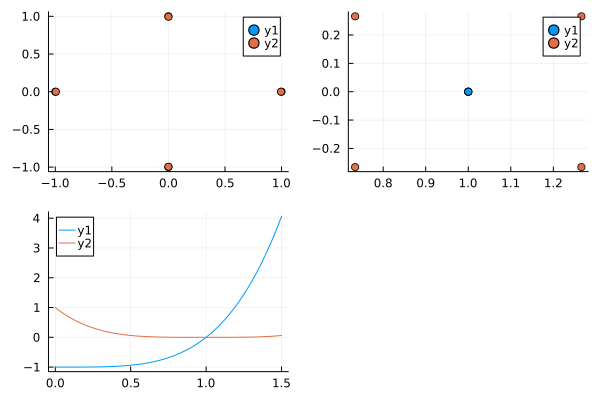

In [ ]:
function perturbed_poly(p,t)
  P=Polynomial(p)
  Q=P+t
  r=range(0.0, 1.5, length=500)
  yP=P.(r)
  yQ=Q.(r)
  s2=plot(r, yP)
  kP=roots(P)
  kQ=roots(Q)
  s1=scatter(real.(kP), imag.(kP))
  s1=scatter!(real.(kQ), imag(kQ))
  return s1, s2
end

a=[-1, 0, 0, 0, 1]
b=[1, -4, 6, -4, 1]

sa1, sa2 = perturbed_poly(a, 0.02)
sb1, sb2 = perturbed_poly(b, 0.02)

w=range(0.0, 1.5, length=500)
ya=Polynomial(a).(w)
yb=Polynomial(b).(w)
sab2=plot(w, ya)
sab2=plot!(w, yb)

plot(sa1, sb1, sab2)

L'Esercizio 1 mostra sperimentalmente come le radici multiple di un polinomio siano in generale mal condizionate: se $p(x)$ ha una radice con molteplicità $k$ e applico ai coefficienti di $p(x)$ una perturbazione dell'ordine di $\epsilon$, la radice multipla si ``spezza'' in $k$ radici distinte a distanza circa $\epsilon^{\frac1k}$.

---
#2. Polinomi di Legendre e Chebyshev

**Esercizio 2**.

1. *Polinomi di Legendre*.
I polinomi di Legendre sono definiti in modo ricorsivo come

\begin{eqnarray*}
&& p_0(x)=1,\\
&& p_1(x)=x,\\
&& p_n(x)=\frac{(2n-1)xp_{n-1}(x)-(n-1)p_{n-2}(x)}{n},\qquad n\geq 2.
\end{eqnarray*}

Scrivere una funzione `legendre(K)` che prenda in ingresso un intero positivo `K` e disegni il grafico dei primi `K` polinomi di Legendre sull'intervallo $[-1,1]$.

In [ ]:
function legen(K)
  p0=Polynomial([1.0])
  p1=Polynomial([0.0, 1.0])
  v=[p0, p1]
  q=p1
  o=p0
  aux=p0

  for i in 2:K
    aux=q
    q=((2*i-1)*p1*q-(i-1)o)/i
    o=aux
    v=push!(v, q)
  end

  t=range(-1.0, 1.0, length=500)
  y=p0.(t)
  s=plot(t, y)

  for p in v
    y=p.(t)

    s=plot!( t, y)
  end

  return s
end

legen (generic function with 1 method)

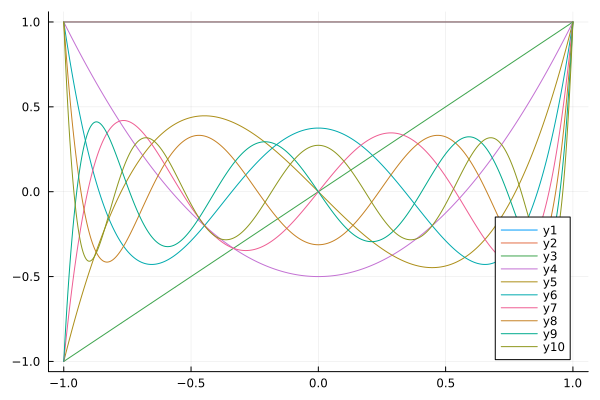

In [ ]:
L=legen(8)
plot(L)

2. *Polinomi di Chebyshev*.
I polinomi di Chebyshev di prima specie sono definiti in modo ricorsivo come

\begin{eqnarray*}
&& p_0(x)=1,\\
&& p_1(x)=x,\\
&& p_n(x)=2xp_{n-1}(x)-p_{n-2}(x),\qquad n\geq 2.
\end{eqnarray*}

Scrivere una funzione `cheby(K)` che prenda in ingresso un intero positivo `K` e disegni il grafico dei primi `K` polinomi di Chebyshev sull'intervallo $[-1,1]$.

In [ ]:
function cheb(K)
  p0=Polynomial([1.0])
  p1=Polynomial([0.0, 1.0])

  v=[p0, p1]
  q=p1
  o=p0
  aux=p0

  for i in 2:K
    aux=q
    q=2*p1*q-o
    o=aux
    v=push!(v, q)
  end

  t=range(-1.0, 1.0, length=500)
  y=p0.(t)
  s=plot(t, y)
  for p in v
    y=p.(t)
    s=plot!(t, y)
  end

  return s
end

cheb (generic function with 1 method)

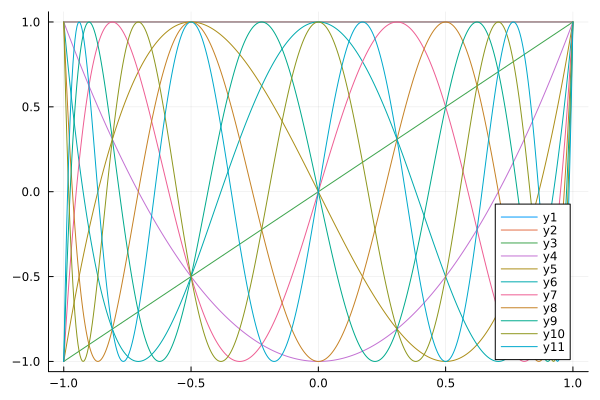

In [ ]:
l=cheb(9)
plot(l)

Osservando i grafici dei polinomi di Legendre e Chebyshev, cosa potete dire delle loro radici?

---
#3. Esponenziale di una matrice e polinomi di Taylor

Data una matrice A di dimensioni $n\times n$, l'esponenziale di $A$ è la matrice
$$
e^A=\sum_{k=0}^{\infty}\frac{A^k}{k!}=I+A+\frac12 A^2+\frac16 A^3+\ldots.
$$
In Julia l'esponenziale di `A` si calcola con la funzione `exp(A)` (da non confondersi con `exp.(A)`, che calcola una matrice i cui elementi sono gli esponenziali degli elementi corrispondenti della matrice `A`)

Vogliamo capire se l'approssimazione di $e^A$ data dai polinomi di Taylor, cioè dalle serie troncate $p_m(A)=I+A+\frac12 A^2+\ldots+\frac{1}{m!}A^m$ converge rapidamente ed è numericamente valida. In altre parole, vogliamo studiare numericamente la successione $\{s_m\}_{m\in\mathbb{N}}$, dove
$$
s_m=\|e^A-p_m(A)\|_2.
$$
E' utile sapere che in Julia la norma 2 di una matrice si calcola con la funzione `norm` e il fattoriale di un numero intero `i` con la funzione `factorial(big(i))` (invece che semplicemente `factorial(i)`, per evitare problemi di rappresentazione dei numeri attraverso il computer).


**Esercizio 3**. Scrivere una funzione `err=convergenza_exp(A,k)` che prenda in ingresso una matrice quadrata `A` e un intero positivo `k`, e restituisca il vettore `err` dei primi `k` elementi della successione $\{s_m\}_{m\in\mathbb{N}}$.

In [61]:
function conver(A, k)
  p0=Polynomial([1.0])
  q=p0
  p=Polynomial([0.0, 1.0])
  v=[p0]
  for i in 2:k
    q=q+(p^i)/(factorial(big(i)))
    push!(v,q)
  end
  err=[]
  l=0.0
  for f in v
    l=norm(exp(A)-f(A))
    push!(err, l)
  end
  return err
end



conver (generic function with 1 method)

Si testi poi la funzione appena definita, disegnando in modo opportuno l'andamento degli errori di approssimazione di $e^A$ nei casi seguenti:

\begin{eqnarray*}
&&A=\left[\begin{array}{ccc}
0&0&0\\ 0&0.2&0\\ 0&0&0.5
\end{array}\right],\\
&&A=\left[\begin{array}{ccc}
1.5&0&0\\ 0&2&0\\ 0&0&5
\end{array}\right],\\
&&A=\left[\begin{array}{cc}
40 & 32 \\ 16& 18
\end{array}\right],\\
&&A=\left[\begin{array}{cc}
-49&24\\-64& 31
\end{array}\right].
\end{eqnarray*}

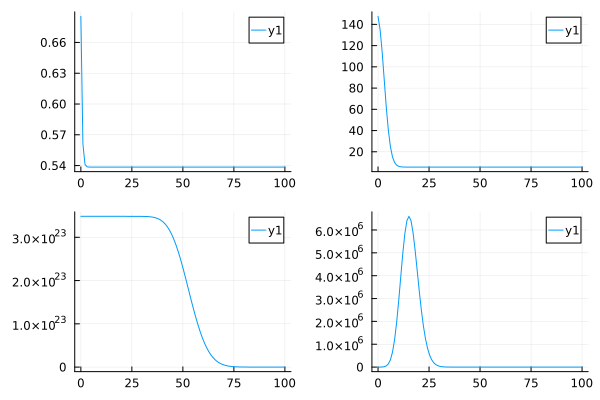

In [63]:
A=[0 0 0; 0 0.2 0; 0 0 0.5]
B=[1.5 0 0; 0 2.0 0 ; 0 0 5.0]
C=[40.0 32.0; 16.0 18.0]
D=[-49.0 24.0; -64.0 31.0]
x=range(0, 100, length=100)
ya=conver(A, 100)
sa=plot(x, ya)
yb=conver(B, 100)
yc=conver(C, 100)
yd=conver(D, 100)
sc=plot(x, yc)
sd=plot(x, yd)
sb=plot(x, yb)
plot(sa, sb, sc, sd)


Che cosa osservate? Quali grandezze associate alla matrice secondo voi influenzano la velocità di convergenza?  